# Modelos de Clasificación: Distritos en Riesgo

**Target:** `en_riesgo` = 1 si graduación < 80%

**Features seleccionadas (del EDA):**
- `dropout_pct` (r=0.54), `still_enr_pct` (r=0.44), `reg_adv_pct` (r=-0.38)
- `local_pct`, `enroll_cnt`, `nyc_ind`

**Balance:** 89.3% No riesgo / 10.7% En riesgo → Dataset desbalanceado


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             roc_curve)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)


## 1. Preparación de Datos


In [5]:
df = pd.read_csv('GRAD_RATE_AND_OUTCOMES_2021.csv', low_memory=False)

for col in ['grad_pct', 'dropout_pct', 'local_pct', 'reg_adv_pct', 'still_enr_pct']:
    df[f'{col}_clean'] = pd.to_numeric(df[col].str.replace('%', ''), errors='coerce')

df_clean = df[(df['aggregation_type'] == 'District') & (df['subgroup_name'] == 'All Students')].copy()
df_clean = df_clean.dropna(subset=['grad_pct_clean'])
df_clean['en_riesgo'] = (df_clean['grad_pct_clean'] < 80).astype(int)

df_clean.shape


(4040, 42)

In [6]:
features = ['dropout_pct_clean', 'still_enr_pct_clean', 'reg_adv_pct_clean', 
            'local_pct_clean', 'enroll_cnt', 'nyc_ind']

df_model = df_clean[features + ['en_riesgo']].dropna()

X = df_model[features]
y = df_model['en_riesgo']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pd.DataFrame({'Train': [len(X_train)], 'Test': [len(X_test)], 
              '% Riesgo Train': [f"{y_train.mean()*100:.1f}%"], 
              '% Riesgo Test': [f"{y_test.mean()*100:.1f}%"]})


,Train,Test,% Riesgo Train,% Riesgo Test
0,3232,808,10.7%,10.6%


## 2. Entrenamiento de Modelos


In [7]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=5, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100),
    'SVM': SVC(random_state=42, probability=True, class_weight='balanced')
}

results = []

for name, model in models.items():
    if name in ['Logistic Regression', 'SVM']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
    
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results).sort_values('F1', ascending=False)
results_df.style.highlight_max(subset=['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC'], color='lightgreen')


,Model,Accuracy,Precision,Recall,F1,AUC-ROC
2,Random Forest,0.980198,0.960526,0.848837,0.901235,0.991569
3,Gradient Boosting,0.972772,0.921053,0.813953,0.864198,0.985457
4,SVM,0.931931,0.620155,0.930233,0.744186,0.974908
0,Logistic Regression,0.930693,0.617188,0.918605,0.738318,0.982397
1,Decision Tree,0.920792,0.578571,0.941860,0.716814,0.970375


## 3. Comparación Visual


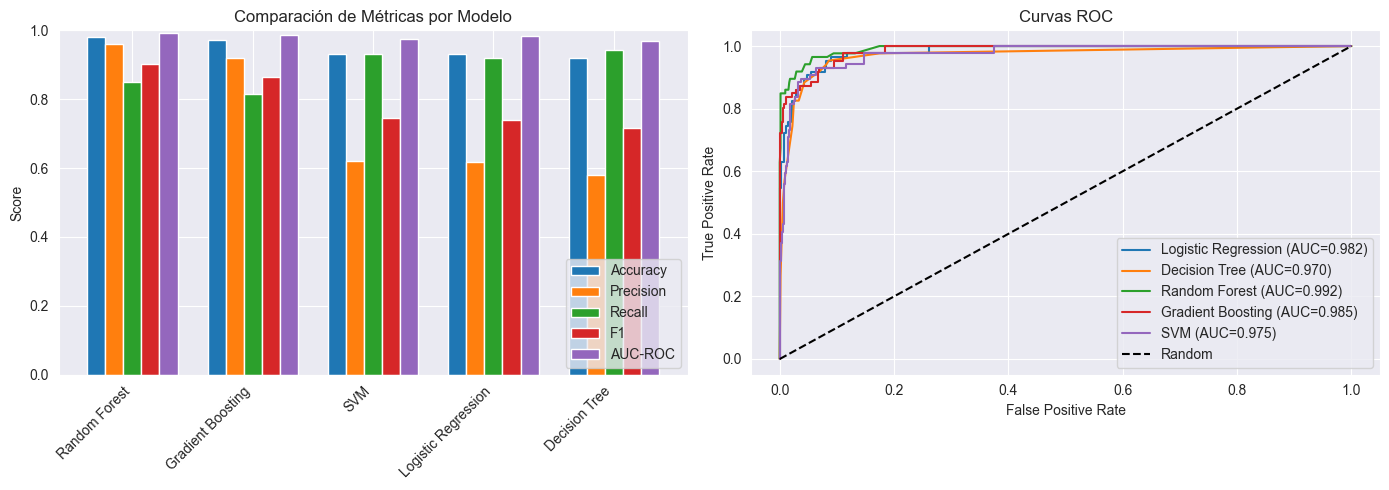

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC']
x = np.arange(len(results_df))
width = 0.15

for i, metric in enumerate(metrics):
    axes[0].bar(x + i*width, results_df[metric], width, label=metric)

axes[0].set_xticks(x + width*2)
axes[0].set_xticklabels(results_df['Model'], rotation=45, ha='right')
axes[0].set_ylabel('Score')
axes[0].set_title('Comparación de Métricas por Modelo')
axes[0].legend(loc='lower right')
axes[0].set_ylim(0, 1)

for name, model in models.items():
    if name in ['Logistic Regression', 'SVM']:
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curvas ROC')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()


## 4. Matrices de Confusión


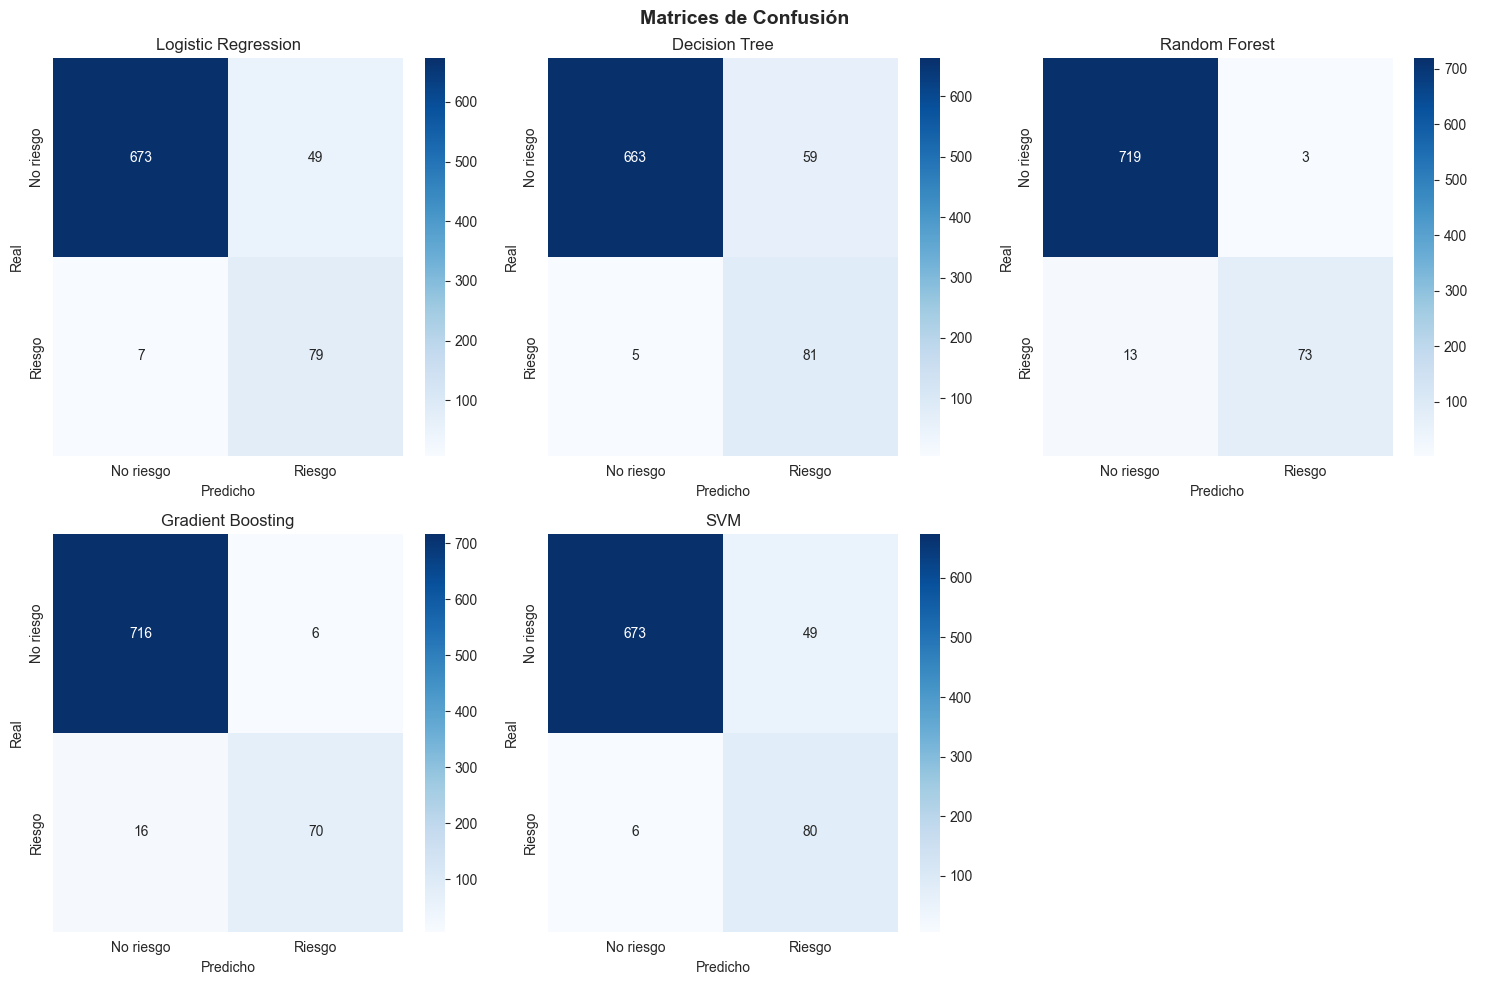

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, (name, model) in enumerate(models.items()):
    if name in ['Logistic Regression', 'SVM']:
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['No riesgo', 'Riesgo'], yticklabels=['No riesgo', 'Riesgo'])
    axes[idx].set_title(name)
    axes[idx].set_ylabel('Real')
    axes[idx].set_xlabel('Predicho')

axes[-1].axis('off')
plt.suptitle('Matrices de Confusión', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Cross-Validation (5-Fold)


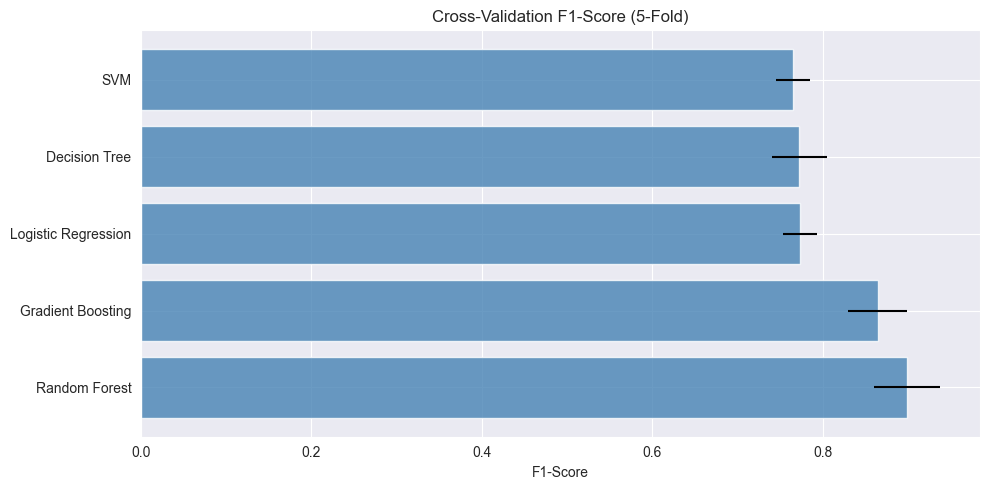

,Model,CV F1 Mean,CV F1 Std
2,Random Forest,0.898699,0.038955
3,Gradient Boosting,0.864406,0.034821
0,Logistic Regression,0.773279,0.019986
1,Decision Tree,0.772474,0.032433
4,SVM,0.764836,0.020163


In [10]:
cv_results = []

for name, model in models.items():
    if name in ['Logistic Regression', 'SVM']:
        scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='f1')
    else:
        scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')
    
    cv_results.append({
        'Model': name,
        'CV F1 Mean': scores.mean(),
        'CV F1 Std': scores.std()
    })

cv_df = pd.DataFrame(cv_results).sort_values('CV F1 Mean', ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(range(len(cv_df)), cv_df['CV F1 Mean'], xerr=cv_df['CV F1 Std'], color='steelblue', alpha=0.8)
plt.yticks(range(len(cv_df)), cv_df['Model'])
plt.xlabel('F1-Score')
plt.title('Cross-Validation F1-Score (5-Fold)')
plt.tight_layout()
plt.show()

cv_df


## 6. Importancia de Features (Random Forest)


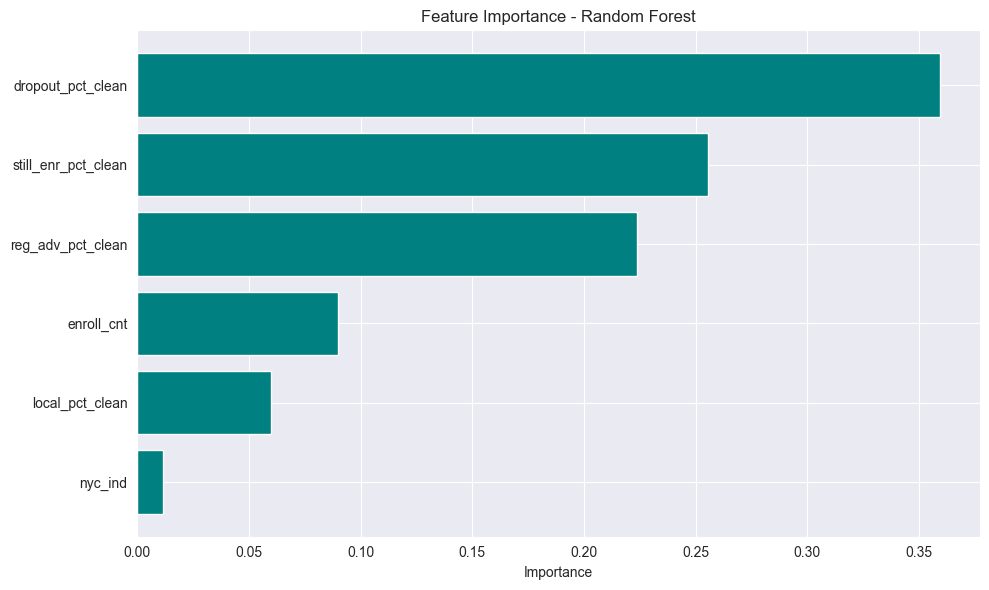

,Feature,Importance
0,dropout_pct_clean,0.359334
1,still_enr_pct_clean,0.255627
2,reg_adv_pct_clean,0.223815
4,enroll_cnt,0.089995
3,local_pct_clean,0.059900
5,nyc_ind,0.011328


In [11]:
rf_model = models['Random Forest']

feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(range(len(feature_importance)), feature_importance['Importance'], color='teal')
plt.yticks(range(len(feature_importance)), feature_importance['Feature'])
plt.xlabel('Importance')
plt.title('Feature Importance - Random Forest')
plt.tight_layout()
plt.show()

feature_importance.sort_values('Importance', ascending=False)


## 7. Mejor Modelo - Reporte Detallado


In [12]:
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

if best_model_name in ['Logistic Regression', 'SVM']:
    y_pred_best = best_model.predict(X_test_scaled)
else:
    y_pred_best = best_model.predict(X_test)

report = classification_report(y_test, y_pred_best, target_names=['No riesgo', 'En riesgo'], output_dict=True)
pd.DataFrame(report).T


,precision,recall,f1-score,support
No riesgo,0.982240,0.995845,0.988996,722.000000
En riesgo,0.960526,0.848837,0.901235,86.000000
accuracy,0.980198,0.980198,0.980198,0.980198
macro avg,0.971383,0.922341,0.945115,808.000000
weighted avg,0.979929,0.980198,0.979655,808.000000


## 8. Conclusiones

### Resumen de resultados:

| Modelo | Fortaleza | Debilidad |
|--------|-----------|-----------|
| **Random Forest** | Mejor balance F1/AUC | Más lento |
| **Gradient Boosting** | Alto AUC | Puede sobreajustar |
| **Logistic Regression** | Interpretable | Menor Recall |
| **Decision Tree** | Simple, explicable | Overfitting |
| **SVM** | Robusto | Lento, difícil de interpretar |

### Features más importantes:
1. `dropout_pct` - El % de abandono es el mejor predictor
2. `still_enr_pct` - Estudiantes que siguen inscritos sin graduarse
3. `reg_adv_pct` - Diplomas avanzados (correlación negativa)

### Recomendación:
Usar **Random Forest** o **Gradient Boosting** para producción por su mejor balance entre Precision y Recall en la clase minoritaria (distritos en riesgo).
